In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class Equilibrium:
    
    R = 8.314
    
    def __init__(self, DrH0, K0, Ea, k0, A0=1.):
        self.DrH0 = DrH0
        self.K0 = K0
        self.Ea = Ea
        self.k0 = k0
        self.A0 = A0
        
    def K(self, T):
        return self.K0 * np.exp(- self.DrH0 / (self.R * T))
    
    def xe(self, T):
        return self.K(T) / (1. + self.K(T))
    
    def k(self, T):
        return self.k0 * np.exp(- self.Ea / (self.R * T))
    
    def v(self, T, x):
        return self.A0 * self.k(T) * (1. - x / self.xe(T))
    
    def x_otp(self, T):
        return self.Ea * self.K(T) / (self.Ea - self.DrH0 + self.Ea * self.K(T))
    

In [3]:
Tlin = np.linspace(250, 500, 500)

In [4]:
model = Equilibrium(-75300, 0.18955e-10, 48721, 530991)

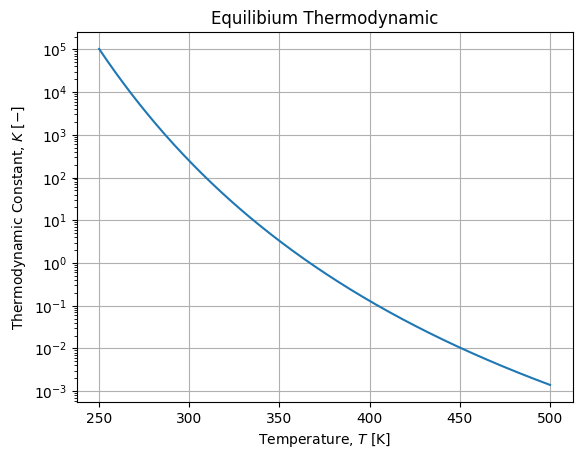

In [5]:
fig, axe = plt.subplots()
axe.semilogy(Tlin, model.K(Tlin))
axe.set_title("Equilibium Thermodynamic")
axe.set_xlabel(r"Temperature, $T$ $[\mathrm{K}]$")
axe.set_ylabel(r"Thermodynamic Constant, $K$ $[-]$")
axe.grid()

In [6]:
vlevels = np.logspace(-6, -1, 15)
xlin = np.linspace(0., 1., 500)
T, X = np.meshgrid(Tlin, xlin)
xisov = model.v(T, X)

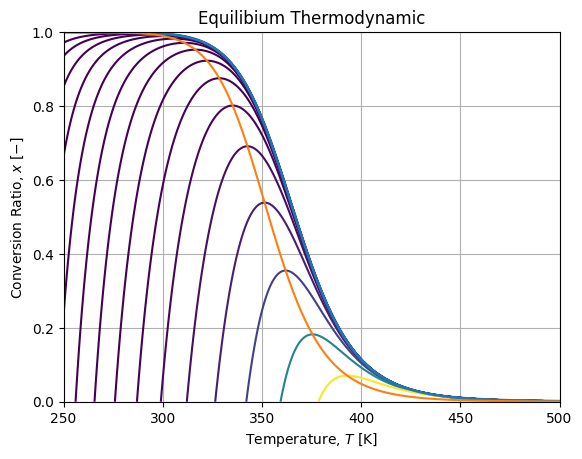

In [9]:
fig, axe = plt.subplots()
c = axe.contour(T, X, xisov, vlevels)
axe.plot(Tlin, model.xe(Tlin), linewidth=2.)
axe.plot(Tlin, model.x_otp(Tlin))
axe.set_title("Equilibium Thermodynamic")
axe.set_xlabel(r"Temperature, $T$ $[\mathrm{K}]$")
axe.set_ylabel(r"Conversion Ratio, $x$ $[-]$")
axe.grid()